✅ Dataset loaded successfully!

📋 First 5 rows of the dataset:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

📐 Dataset shape: 1000 rows × 9 columns

🔎 Column names and data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Categor

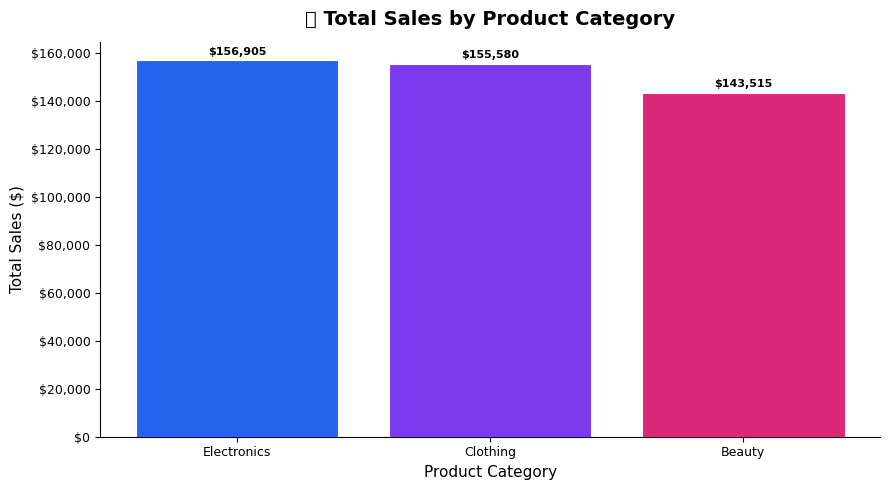

✅ Chart saved: sales_by_category.png


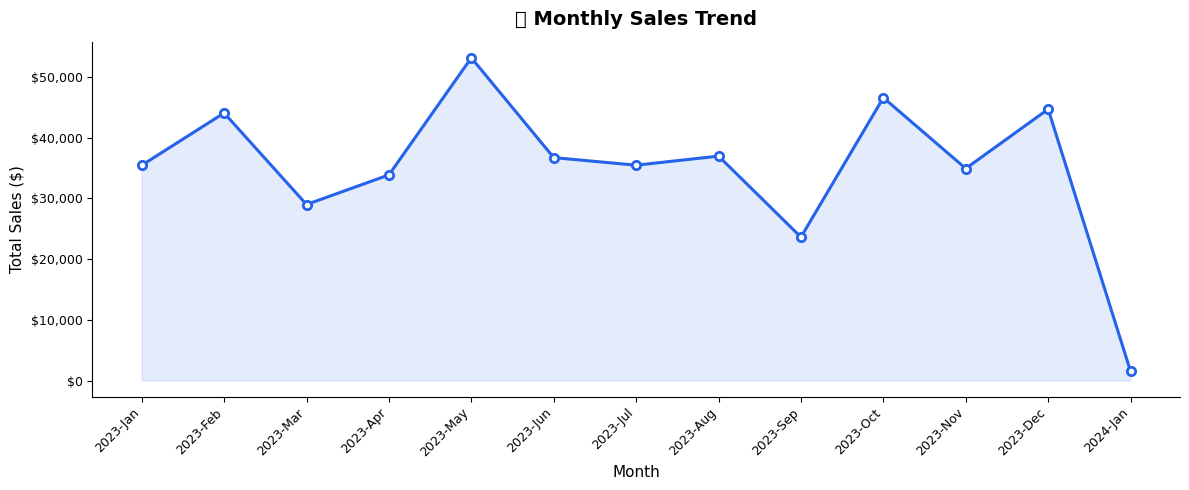

✅ Chart saved: monthly_sales_trend.png


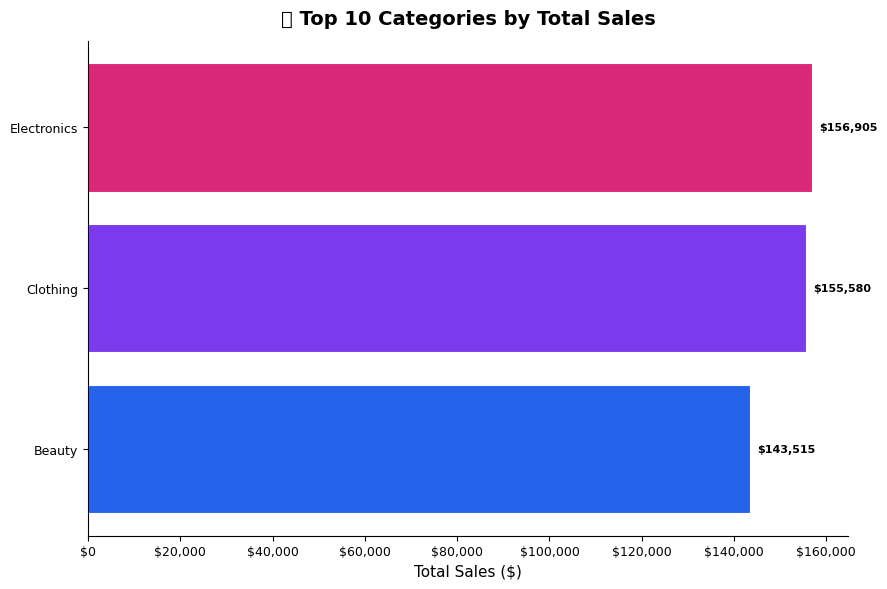

✅ Chart saved: top_products.png


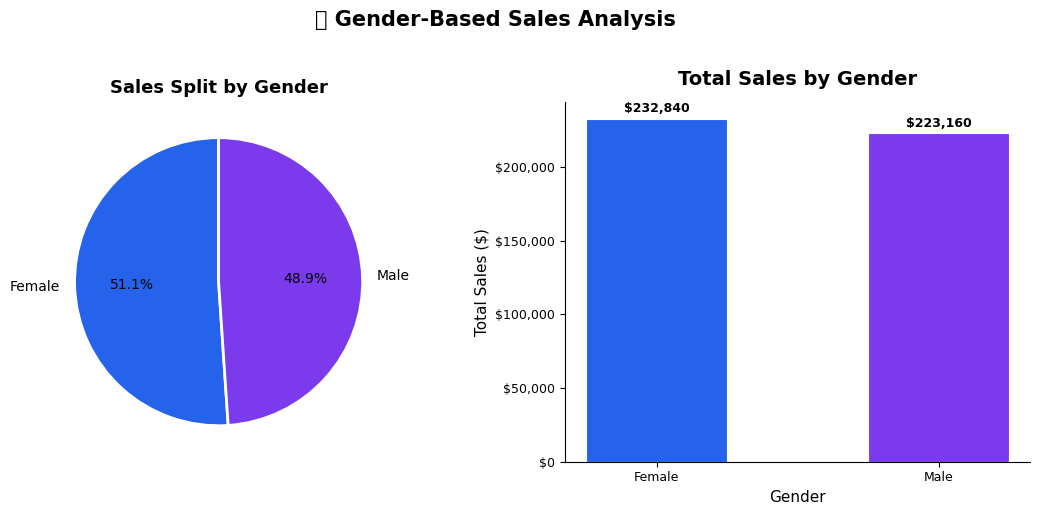

✅ Chart saved: sales_by_gender.png

🎉 All analysis complete! Files saved:
   • sales_by_category.png
   • monthly_sales_trend.png
   • top_products.png
   • sales_by_gender.png


In [2]:
# ============================================================
# RETAIL SALES DASHBOARD - Data Analytics Portfolio Project
# Tools: Python, Pandas, Matplotlib
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Optional: suppress font warnings on some systems ────────
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# STEP 1 — LOAD THE DATASET
# ============================================================

df = pd.read_csv("retail_sales_dataset.csv")

print("=" * 50)
print("✅ Dataset loaded successfully!")
print("=" * 50)


# ============================================================
# STEP 2 — PREVIEW THE DATA
# ============================================================

print("\n📋 First 5 rows of the dataset:")
print(df.head())

print(f"\n📐 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n🔎 Column names and data types:")
print(df.dtypes)


# ============================================================
# STEP 3 — CLEAN MISSING VALUES
# ============================================================

print("\n🧹 Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows where critical columns are completely empty
df.dropna(subset=["Transaction ID", "Date", "Total Amount"], inplace=True)

# For numeric columns, fill any remaining gaps with the column median
numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# For text columns, fill gaps with 'Unknown'
text_cols = ["Gender", "Product Category"]
for col in text_cols:
    if col in df.columns:
        df[col].fillna("Unknown", inplace=True)

print("\n✅ Missing values after cleaning:")
print(df.isnull().sum())


# ============================================================
# STEP 4 — CONVERT DATES
# ============================================================

# Convert the Date column to a proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Extract useful time components for later analysis
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month Name"] = df["Date"].dt.strftime("%b")   # e.g. 'Jan', 'Feb'

print("\n📅 Date column converted. Sample:")
print(df[["Date", "Year", "Month", "Month Name"]].head(3))


# ============================================================
# STEP 5 — SUMMARY STATISTICS
# ============================================================

print("\n📊 Summary Statistics:")
print(df.describe())

print(f"\n💰 Total Revenue:     ${df['Total Amount'].sum():,.2f}")
print(f"🛒 Total Transactions: {len(df):,}")
print(f"📦 Avg Order Value:   ${df['Total Amount'].mean():,.2f}")


# ============================================================
# SHARED STYLE HELPER
# ============================================================

COLORS = ["#2563EB", "#7C3AED", "#DB2777", "#D97706",
          "#059669", "#DC2626", "#0891B2", "#65A30D",
          "#9333EA", "#EA580C"]

def style_ax(ax, title, xlabel="", ylabel=""):
    """Apply a clean, consistent style to any chart axis."""
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    ax.tick_params(axis="both", labelsize=9)


# ============================================================
# STEP 6 — SALES BY PRODUCT CATEGORY
# ============================================================

category_sales = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    category_sales.index,
    category_sales.values,
    color=COLORS[:len(category_sales)],
    edgecolor="white",
    linewidth=0.8
)

# Add value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + category_sales.max() * 0.01,
        f"${bar.get_height():,.0f}",
        ha="center", va="bottom", fontsize=8, fontweight="bold"
    )

style_ax(ax, "💼 Total Sales by Product Category",
         xlabel="Product Category", ylabel="Total Sales ($)")

plt.tight_layout()
plt.savefig("sales_by_category.png", dpi=150)
plt.show()
print("✅ Chart saved: sales_by_category.png")


# ============================================================
# STEP 7 — MONTHLY SALES TRENDS
# ============================================================

# Group by Year + Month so multiple years don't collapse together
monthly_sales = (
    df.groupby(["Year", "Month"])["Total Amount"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

# Build a readable label like "2023-Jan"
monthly_sales["Label"] = (
    monthly_sales["Year"].astype(str) + "-" +
    pd.to_datetime(monthly_sales["Month"], format="%m").dt.strftime("%b")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_sales["Label"],
    monthly_sales["Total Amount"],
    color=COLORS[0],
    marker="o",
    linewidth=2.2,
    markersize=6,
    markerfacecolor="white",
    markeredgewidth=2
)

ax.fill_between(
    monthly_sales["Label"],
    monthly_sales["Total Amount"],
    alpha=0.12,
    color=COLORS[0]
)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha="right", fontsize=8)
style_ax(ax, "📈 Monthly Sales Trend", xlabel="Month", ylabel="Total Sales ($)")

plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=150)
plt.show()
print("✅ Chart saved: monthly_sales_trend.png")


# ============================================================
# STEP 8 — TOP 10 PRODUCTS BY SALES
# ============================================================

# NOTE: This dataset uses Product Category, not individual product names.
# If your CSV has a 'Product Name' column, replace 'Product Category' below.

top_products = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 6))

# Horizontal bar chart — easier to read long product names
bars = ax.barh(
    top_products.index[::-1],   # reverse so highest is at the top
    top_products.values[::-1],
    color=COLORS[:len(top_products)],
    edgecolor="white",
    linewidth=0.8
)

# Add value labels at end of each bar
for bar in bars:
    ax.text(
        bar.get_width() + top_products.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center", fontsize=8, fontweight="bold"
    )

ax.set_title("🏆 Top 10 Categories by Total Sales",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Total Sales ($)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.savefig("top_products.png", dpi=150)
plt.show()
print("✅ Chart saved: top_products.png")


# ============================================================
# STEP 9 — SALES BY GENDER
# ============================================================
# NOTE: Your dataset doesn't include a Region column, so we
# analyse sales by Gender instead — a great demographic insight.
# If your CSV has a 'Region' column, swap 'Gender' for 'Region'.

gender_sales = (
    df.groupby("Gender")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ── Left: Pie chart ─────────────────────────────────────────
axes[0].pie(
    gender_sales.values,
    labels=gender_sales.index,
    autopct="%1.1f%%",
    colors=COLORS[:len(gender_sales)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Sales Split by Gender", fontsize=13, fontweight="bold")

# ── Right: Bar chart ────────────────────────────────────────
bars = axes[1].bar(
    gender_sales.index,
    gender_sales.values,
    color=COLORS[:len(gender_sales)],
    edgecolor="white",
    linewidth=0.8,
    width=0.5
)

for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + gender_sales.max() * 0.01,
        f"${bar.get_height():,.0f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

style_ax(axes[1], "Total Sales by Gender",
         xlabel="Gender", ylabel="Total Sales ($)")

plt.suptitle("👤 Gender-Based Sales Analysis",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sales_by_gender.png", dpi=150)
plt.show()
print("✅ Chart saved: sales_by_gender.png")


# ============================================================
# DONE — SUMMARY
# ============================================================

print("\n" + "=" * 50)
print("🎉 All analysis complete! Files saved:")
print("   • sales_by_category.png")
print("   • monthly_sales_trend.png")
print("   • top_products.png")
print("   • sales_by_gender.png")
print("=" * 50)